In [1]:
import pandas as pd
import numpy as np
import shap
import joblib

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

In [2]:
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [3]:
model = joblib.load(
    "../results/fraud_detection_xgb.pkl"
)

scaler = joblib.load(
    "../results/scaler.pkl"
)

In [4]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9938764977176296, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='aucpr', feature_types=None, feature_weights=None,
              gamma=2.426447357015321, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07178615670002696,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=320, n_jobs=-1,
              num_parallel_tree=None, ...)


In [5]:
df = pd.read_csv(
    "../data/raw/creditcard.csv"
)

X = df.drop("Class", axis=1)
y = df["Class"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [7]:
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.transform(
    X_train[["Time", "Amount"]]
)

X_val[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [8]:
explainer = shap.TreeExplainer(model)

In [9]:
explainer = shap.TreeExplainer(model)

In [11]:
X_sample = X_test.sample(
    n=1000,
    random_state=42
)



In [12]:
shap_values = explainer(
    X_sample
)

In [13]:
print(shap_values)

.values =
array([[-0.6476696 ,  0.03348852, -0.15478957, ..., -0.4625596 ,
        -0.21699278, -0.29537594],
       [-0.26880804,  0.0309088 , -0.15051007, ..., -0.5601424 ,
        -0.0967104 ,  0.37386557],
       [-0.07424513, -0.86621743, -0.0480604 , ..., -0.16324459,
        -0.18441366, -0.27010787],
       ...,
       [ 0.19346964, -0.30990553, -0.25283626, ..., -0.13388419,
         0.02558262, -0.43020353],
       [-0.67721105, -0.2502858 , -0.1474006 , ..., -0.16369274,
        -0.03781652, -0.2229295 ],
       [-0.63439107,  0.01923688, -0.7070092 , ..., -0.22666246,
        -0.22547561, -0.471617  ]], shape=(1000, 30), dtype=float32)

.base_values =
array([1.6413522, 1.6413522, 1.6413522, 1.6413522, 1.6413522, 1.6413522,
       1.6413522, 1.6413522, 1.6413522, 1.6413522, 1.6413522, 1.6413522,
       1.6413522, 1.6413522, 1.6413522, 1.6413522, 1.6413522, 1.6413522,
       1.6413522, 1.6413522, 1.6413522, 1.6413522, 1.6413522, 1.6413522,
       1.6413522, 1.6413522, 1.64135

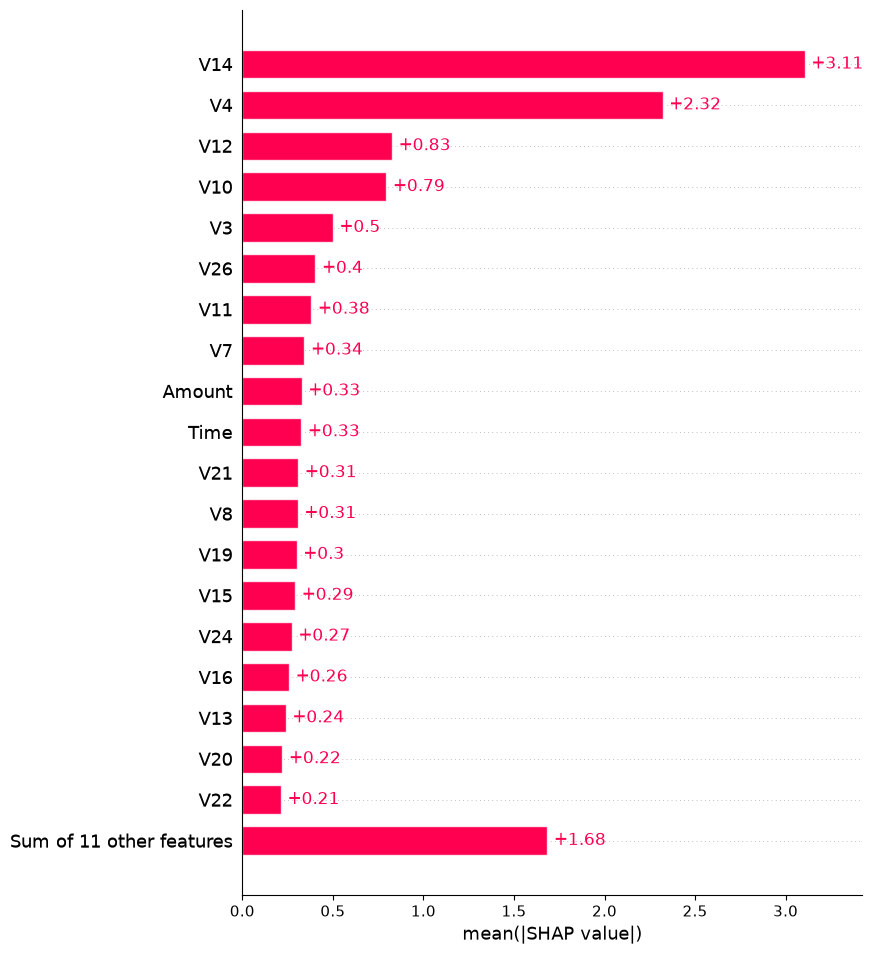

In [14]:
shap.plots.bar(
    shap_values,
    max_display=20
)

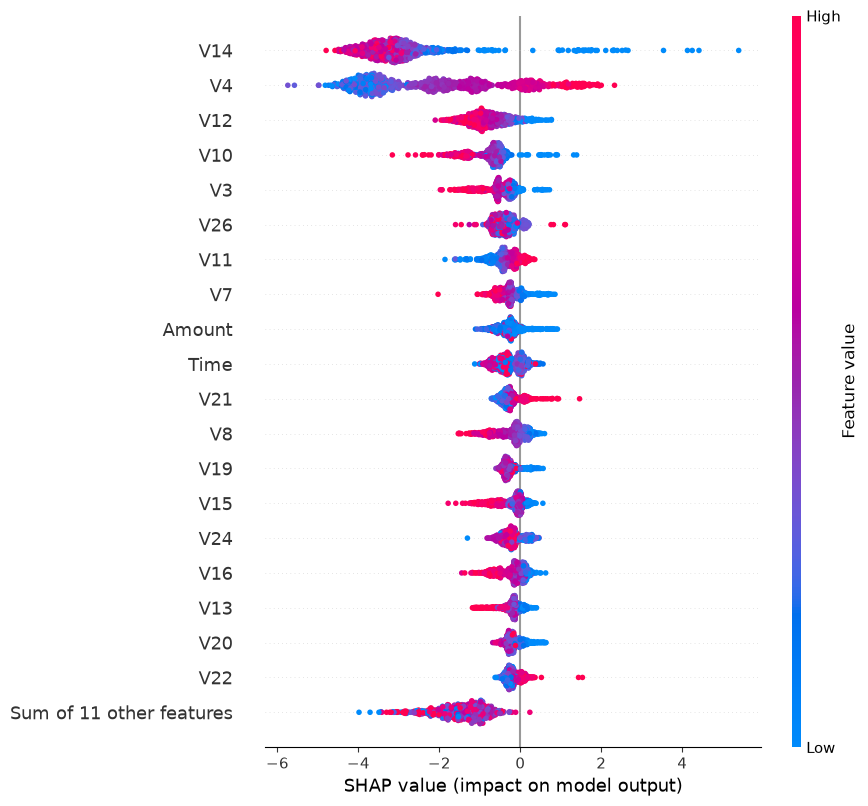

In [15]:
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

In [16]:
fraud_indices = y_test[
    y_test == 1
].index

fraud_index = fraud_indices[0]

fraud_transaction = X_test.loc[
    [fraud_index]
]

In [17]:
fraud_transaction

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
280143,1.567679,1.378559,1.289381,-5.004247,1.41185,0.442581,-1.326536,-1.41317,0.248525,-1.127396,...,0.226138,0.370612,0.028234,-0.14564,-0.081049,0.521875,0.739467,0.389152,0.186637,-0.346253


In [18]:
fraud_probability = model.predict_proba(
    fraud_transaction
)[0, 1]

print(
    f"Fraud probability: {fraud_probability:.4f}"
)

Fraud probability: 0.9995


In [19]:
fraud_shap = explainer(
    fraud_transaction
)

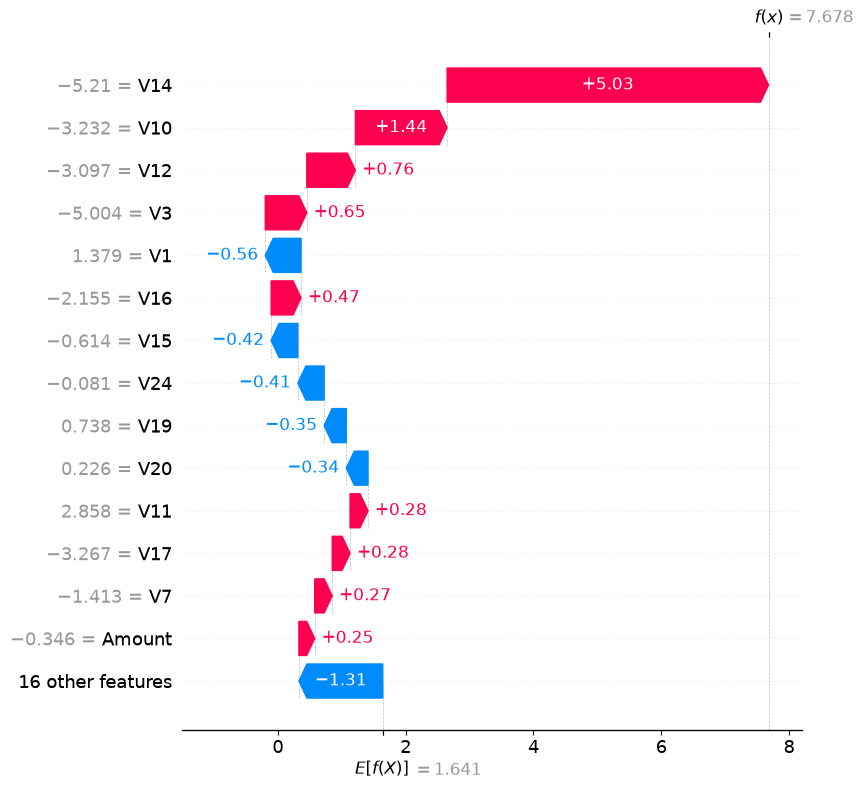

In [20]:
shap.plots.waterfall(
    fraud_shap[0],
    max_display=15
)

In [21]:
legit_indices = y_test[
    y_test == 0
].index

legit_index = legit_indices[0]

legit_transaction = X_test.loc[
    [legit_index]
]

In [22]:
legit_probability = model.predict_proba(
    legit_transaction
)[0, 1]

print(
    f"Fraud probability: {legit_probability:.4f}"
)

Fraud probability: 0.0000


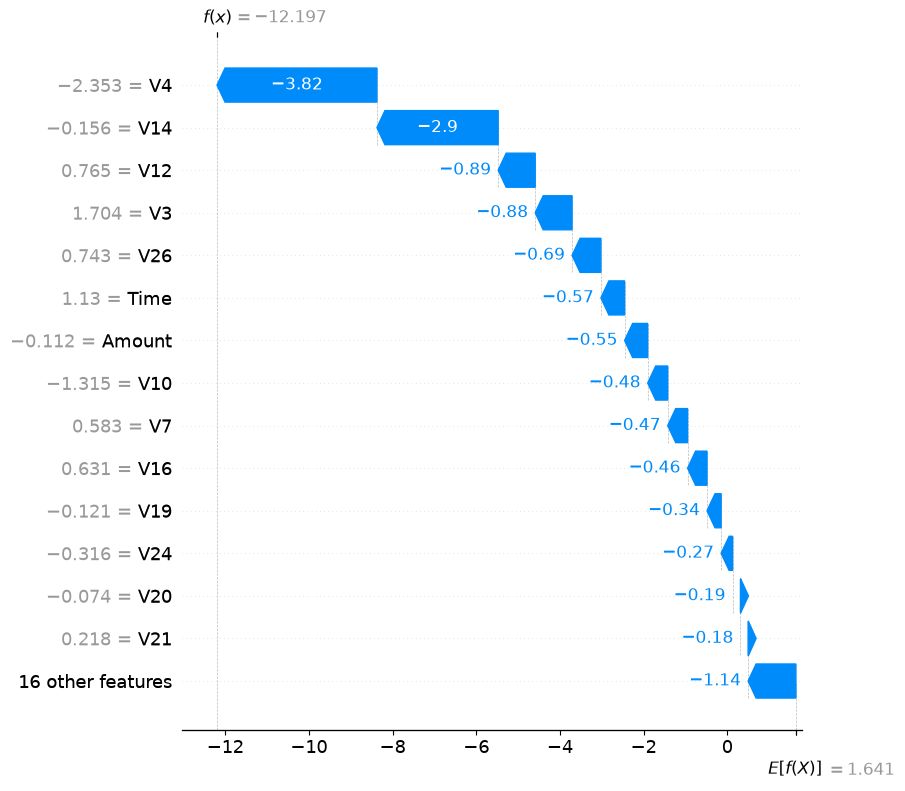

In [23]:
legit_shap = explainer(
    legit_transaction
)

shap.plots.waterfall(
    legit_shap[0],
    max_display=15
)

In [24]:
def explain_transaction(
    transaction,
    model,
    explainer
):

    probability = model.predict_proba(
        transaction
    )[0, 1]

    prediction = (
        "Fraud"
        if probability >= 0.5
        else "Legitimate"
    )

    shap_result = explainer(
        transaction
    )

    return {
        "prediction": prediction,
        "fraud_probability": probability,
        "shap_values": shap_result
    }

In [25]:
result = explain_transaction(
    fraud_transaction,
    model,
    explainer
)

print(
    result["prediction"]
)

print(
    result["fraud_probability"]
)

Fraud
0.99953735


In [26]:
def top_feature_contributions(
    transaction,
    explainer,
    top_n=5
):

    explanation = explainer(
        transaction
    )

    values = explanation.values[0]

    features = transaction.columns

    contributions = pd.DataFrame({
        "feature": features,
        "shap_value": values
    })

    contributions["abs_shap"] = (
        contributions["shap_value"].abs()
    )

    contributions = contributions.sort_values(
        "abs_shap",
        ascending=False
    )

    return contributions.head(top_n)

In [27]:
top_feature_contributions(
    fraud_transaction,
    explainer
)

,feature,shap_value,abs_shap
14,V14,5.030160,5.030160
10,V10,1.435271,1.435271
12,V12,0.760549,0.760549
3,V3,0.649773,0.649773
1,V1,-0.559887,0.559887


In [29]:
mkdir -p ../results/shap

In [30]:
global_importance = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": np.abs(
        shap_values.values
    ).mean(axis=0)
})

global_importance = global_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

global_importance.to_csv(
    "../results/shap/global_feature_importance.csv",
    index=False
)

In [31]:
fraud_transaction_raw = df[
    df["Class"] == 1
].drop("Class", axis=1).iloc[0]

fraud_transaction_raw.to_dict()

{'Time': 406.0,
 'V1': -2.3122265423263,
 'V2': 1.95199201064158,
 'V3': -1.60985073229769,
 'V4': 3.9979055875468,
 'V5': -0.522187864667764,
 'V6': -1.42654531920595,
 'V7': -2.53738730624579,
 'V8': 1.39165724829804,
 'V9': -2.77008927719433,
 'V10': -2.77227214465915,
 'V11': 3.20203320709635,
 'V12': -2.89990738849473,
 'V13': -0.595221881324605,
 'V14': -4.28925378244217,
 'V15': 0.389724120274487,
 'V16': -1.14074717980657,
 'V17': -2.83005567450437,
 'V18': -0.0168224681808257,
 'V19': 0.416955705037907,
 'V20': 0.126910559061474,
 'V21': 0.517232370861764,
 'V22': -0.0350493686052974,
 'V23': -0.465211076182388,
 'V24': 0.320198198514526,
 'V25': 0.0445191674731724,
 'V26': 0.177839798284401,
 'V27': 0.261145002567677,
 'V28': -0.143275874698919,
 'Amount': 0.0}